# IMC Pancreas - Graph classificiation evaluation

In [12]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
## Plotting
import matplotlib.pyplot as plt
import seaborn as sns

import InterScale as interscale
from InterScale.config import load_config
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule
#from InterScale.eval.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
from InterScale.tl import prepare_a2d_dataset
from InterScale.evaluation import scale_cls_by_sample

from pathlib import Path
import torch
import os

In [37]:
HPC = "/home/icb/francesca.drummer/1-Projects/"
LRZ = "/dss/dsshome1/05/di93tig/1_projects/" 

CFG_CLASS = f"{ICB}GT-long-range-niches/src/config_files/damond19/damond19_class_graph_Combined_condition.yaml"

RESULTS_DIR = "/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/damond19/"

## Load pretrained models

In [3]:
cfg = load_config(CFG_CLASS)

In [4]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 1283580 × 38
    obs: 'ImageNumber', 'ObjectNumber', 'Location_Center_X', 'Location_Center_Y', 'Number_Object_Number', 'image_name', 'id', 'CellCat', 'CellType', 'case', 'slide', 'part', 'group', 'stage', 'duration', 'Aab status', 'Age', 'Gender', 'Ethnicity', 'BMI', 'sliding_window_assignment', 'split'
    uns: 'morphology', 'neighbors', 'parent_structure', 'spatial_neighbors'
    obsm: 'spatial'
    layers: 'MeanIntensity', 'MedianIntensity', 'pct-norm-99'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [5]:
adata.obsm['spatial']

array([[164.,   0.],
       [169.,   0.],
       [340.,   0.],
       ...,
       [134., 328.],
       [157., 328.],
       [376., 328.]])

In [6]:
# import torch

# model = torch.load('/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/cosmx_pancreas/pancreas_regr_node_GCN__model.pt')
# state_dict = model['state_dict']

Want to load from: '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/melton25/melton25_clas_graph_44_GCN_self-attn-transformer_model.ckpt'

In [7]:
#interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
#local_model = interscale.model.LocalModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = False, wandb_save = True)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
combined_model = interscale.model.CombinedModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = True, wandb_save = True)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[pct-norm-99] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


WeightedCE with class weights:  tensor([1.1033, 0.9875, 0.9251], dtype=torch.float64)


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading model from /lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/damond19/damond19_clas_graph_44_GCN_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [8]:
combined_model

## Inference 

In [9]:
np.unique(adata.obs['stage'])

array(['Long-duration', 'Non-diabetic', 'Onset'], dtype=object)

In [10]:
result_long = combined_model.get_model_output(adata[adata.obs['stage'] == 'Long-duration'], prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[pct-norm-99] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Load GEX from .layers/pct-norm-99
call new
{'stage': ['Long-duration']}


In [15]:
result_long.write(os.path.join(RESULTS_DIR, 'result_long.h5ad'))

In [11]:
result_nd = combined_model.get_model_output(adata[adata.obs['stage'] == 'Non-diabetic'], prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[pct-norm-99] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Load GEX from .layers/pct-norm-99
call new
{'stage': ['Non-diabetic']}


In [16]:
result_nd.write(os.path.join(RESULTS_DIR, 'result_nd.h5ad'))

In [17]:
result_onset = combined_model.get_model_output(adata[adata.obs['stage'] == 'Onset'], prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[pct-norm-99] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Load GEX from .layers/pct-norm-99
call new
{'stage': ['Onset']}


In [18]:
result_onset.write(os.path.join(RESULTS_DIR, 'result_onset.h5ad'))

## Evaluation score

In [34]:
from InterScale.evaluation import calculate_pr_auc

## Graph Label analysis

First, we scale the CLS token and then calculate the average mean expression of the CLS (horizontal and vertical) token per cell type.

In [19]:
from InterScale.evaluation.graph_classification import scale_cls_by_sample
scale_cls_by_sample(result_long, "sliding_window_assignment")
scale_cls_by_sample(result_nd, "sliding_window_assignment")
scale_cls_by_sample(result_onset, "sliding_window_assignment")

/localscratch/francesca.drummer/ipykernel_2223250/4097399755.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  processed_data[key] = adata_filtered.obs.groupby(group_by).agg(**agg_dict)
/localscratch/francesca.drummer/ipykernel_2223250/4097399755.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  processed_data[key] = adata_filtered.obs.groupby(group_by).agg(**agg_dict)
/localscratch/francesca.drummer/ipykernel_2223250/4097399755.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or

Figure saved to: /home/icb/francesca.drummer/1-Projects//InterScale_reproducibility/figures/damond19/graph_class/cls_CellCat.png


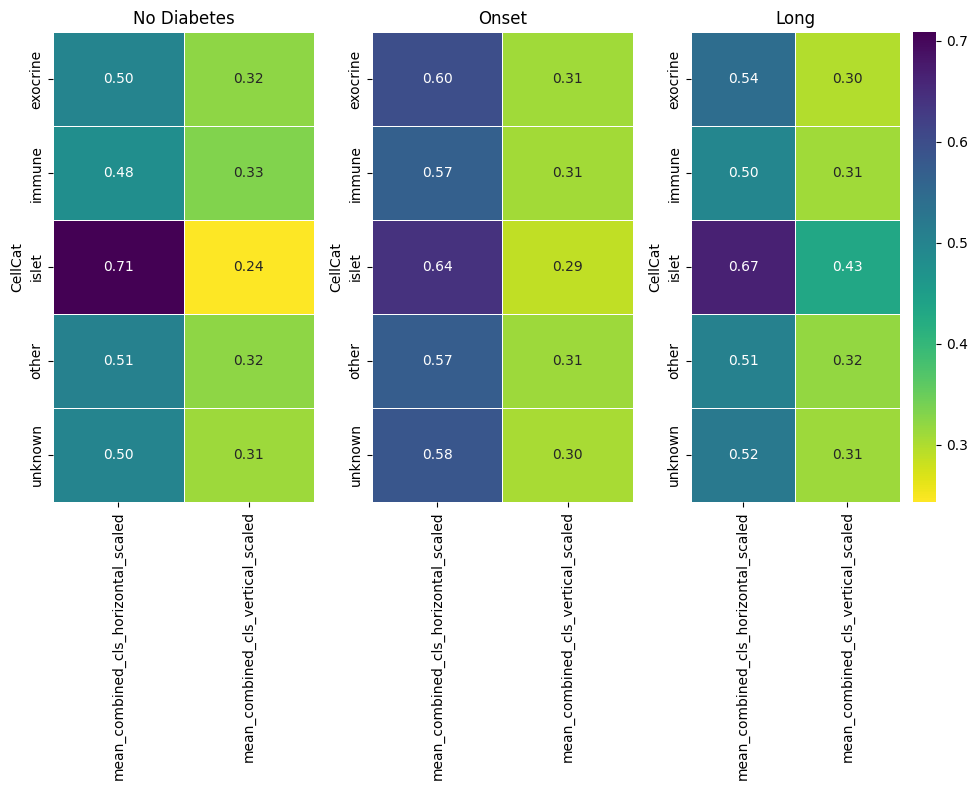

In [77]:
fig = plot_adata_grouped_heatmaps(
        adata_dict={'ND': result_nd, 'Onset': result_onset, 'Long': result_long},
        group_by='CellCat',
        #value_cols=['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled'],
        labels=['No Diabetes', 'Onset', 'Long'],
    agg_func='mean',
        figsize=(10, 8),
        save_path=f"{HPC}/InterScale_reproducibility/figures/damond19/graph_class/cls_CellCat.png"
    )

/localscratch/francesca.drummer/ipykernel_2223250/4097399755.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  processed_data[key] = adata_filtered.obs.groupby(group_by).agg(**agg_dict)
/localscratch/francesca.drummer/ipykernel_2223250/4097399755.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  processed_data[key] = adata_filtered.obs.groupby(group_by).agg(**agg_dict)
/localscratch/francesca.drummer/ipykernel_2223250/4097399755.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or

Figure saved to: /home/icb/francesca.drummer/1-Projects//InterScale_reproducibility/figures/damond19/graph_class/cls_CellType.png


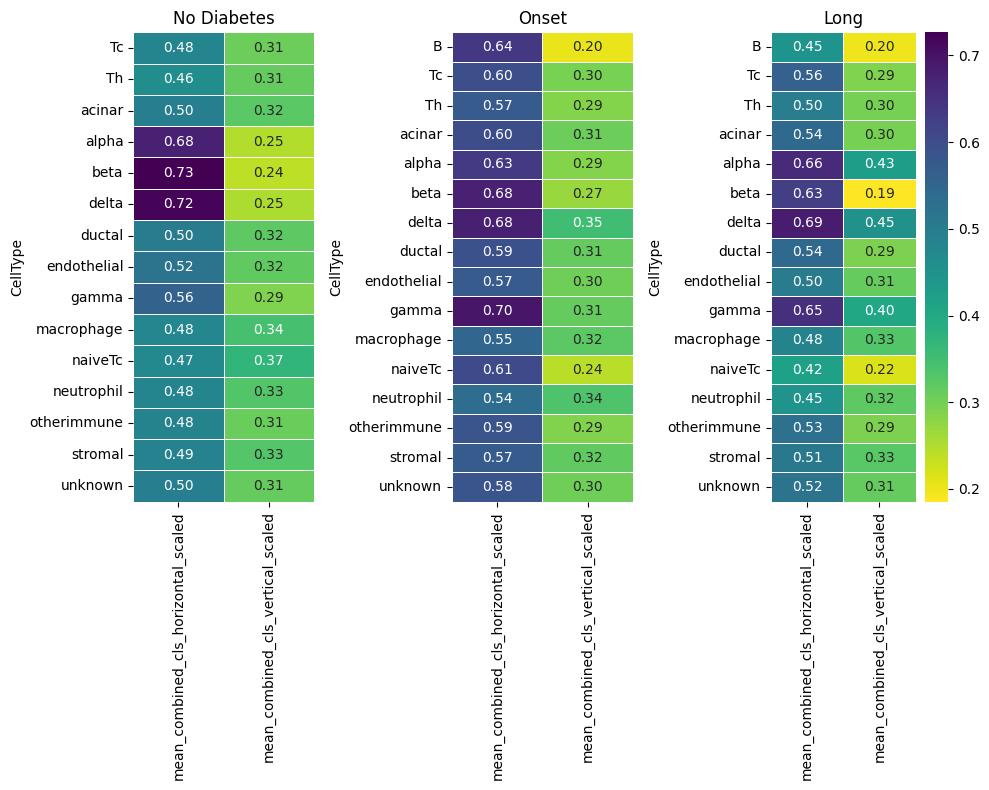

In [78]:
fig = plot_adata_grouped_heatmaps(
        adata_dict={'ND': result_nd, 'Onset': result_onset, 'Long': result_long},
        group_by='CellType',
        #value_cols=['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled'],
        labels=['No Diabetes', 'Onset', 'Long'],
    agg_func='mean',
        figsize=(10, 8),
        save_path=f"{HPC}/InterScale_reproducibility/figures/damond19/graph_class/cls_CellType.png"
    )

[99, 106]


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


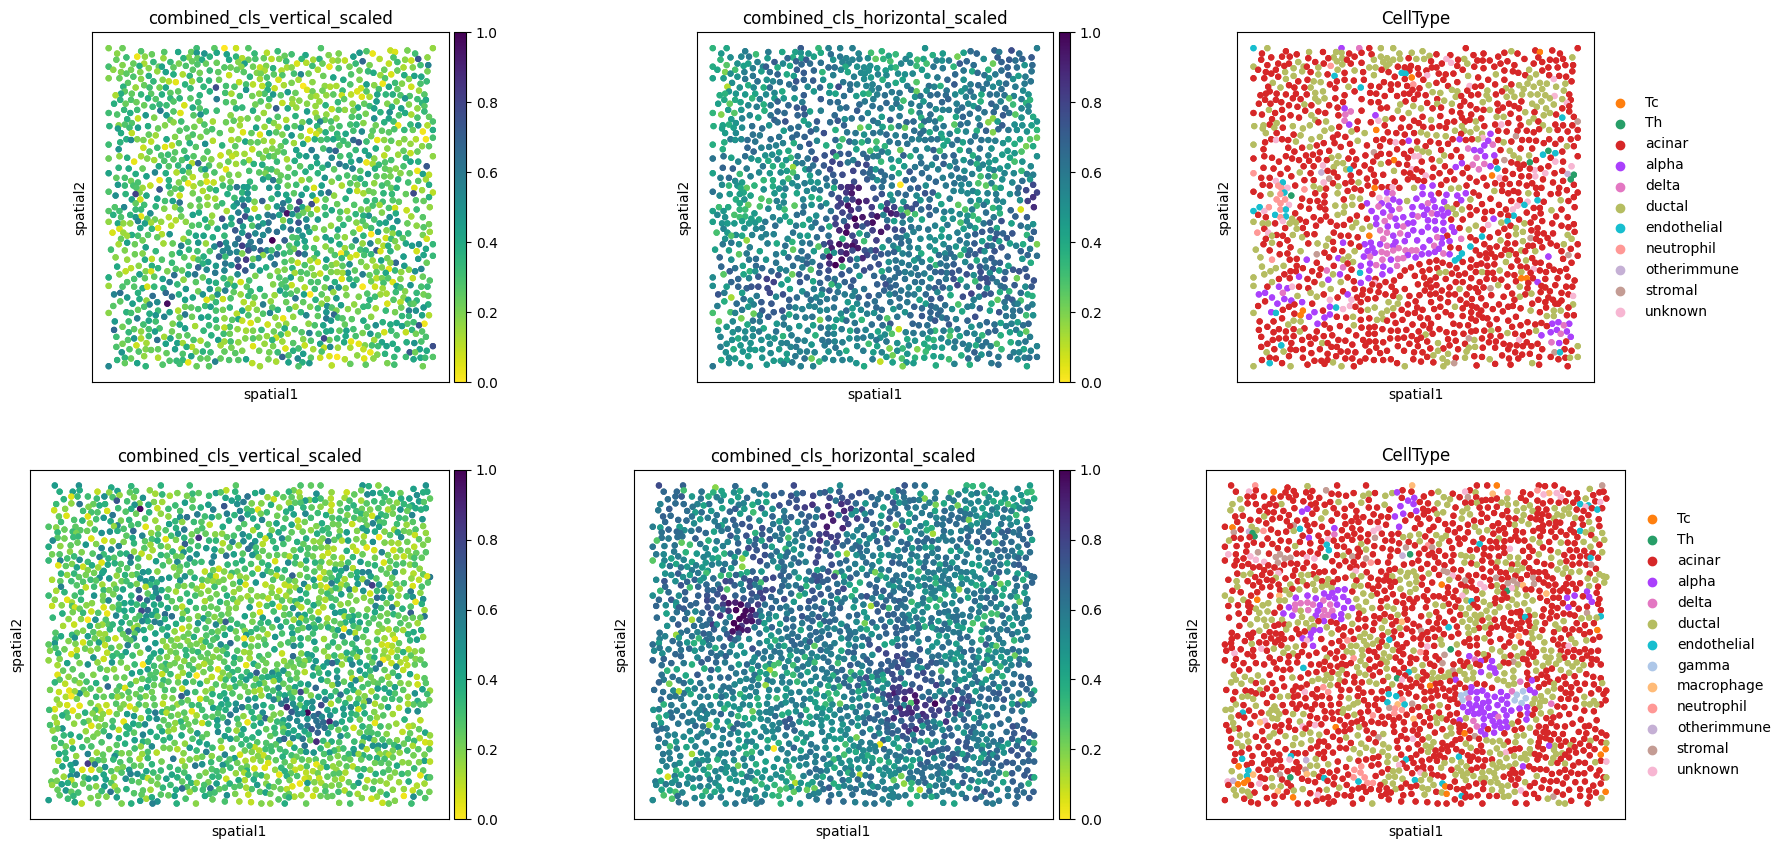

In [76]:
image_nr_long = np.unique(result_long.obs['ImageNumber'][result_long.obs['split'] == 'test'])
image_subset = list(np.random.choice(image_nr_long, 2))
print(image_subset)
sq.pl.spatial_scatter(result_long[result_long.obs['split'] == 'test'], 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', 'CellType'],
                      library_key = 'ImageNumber',
                      library_id = image_subset,
                    cmap = 'viridis_r',
                    shape= None,
                      ncols = 3,
                      size = 50,
                      save = f"{HPC}/InterScale_reproducibility/figures/damond19/graph_class/"
)

[51, 17]


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


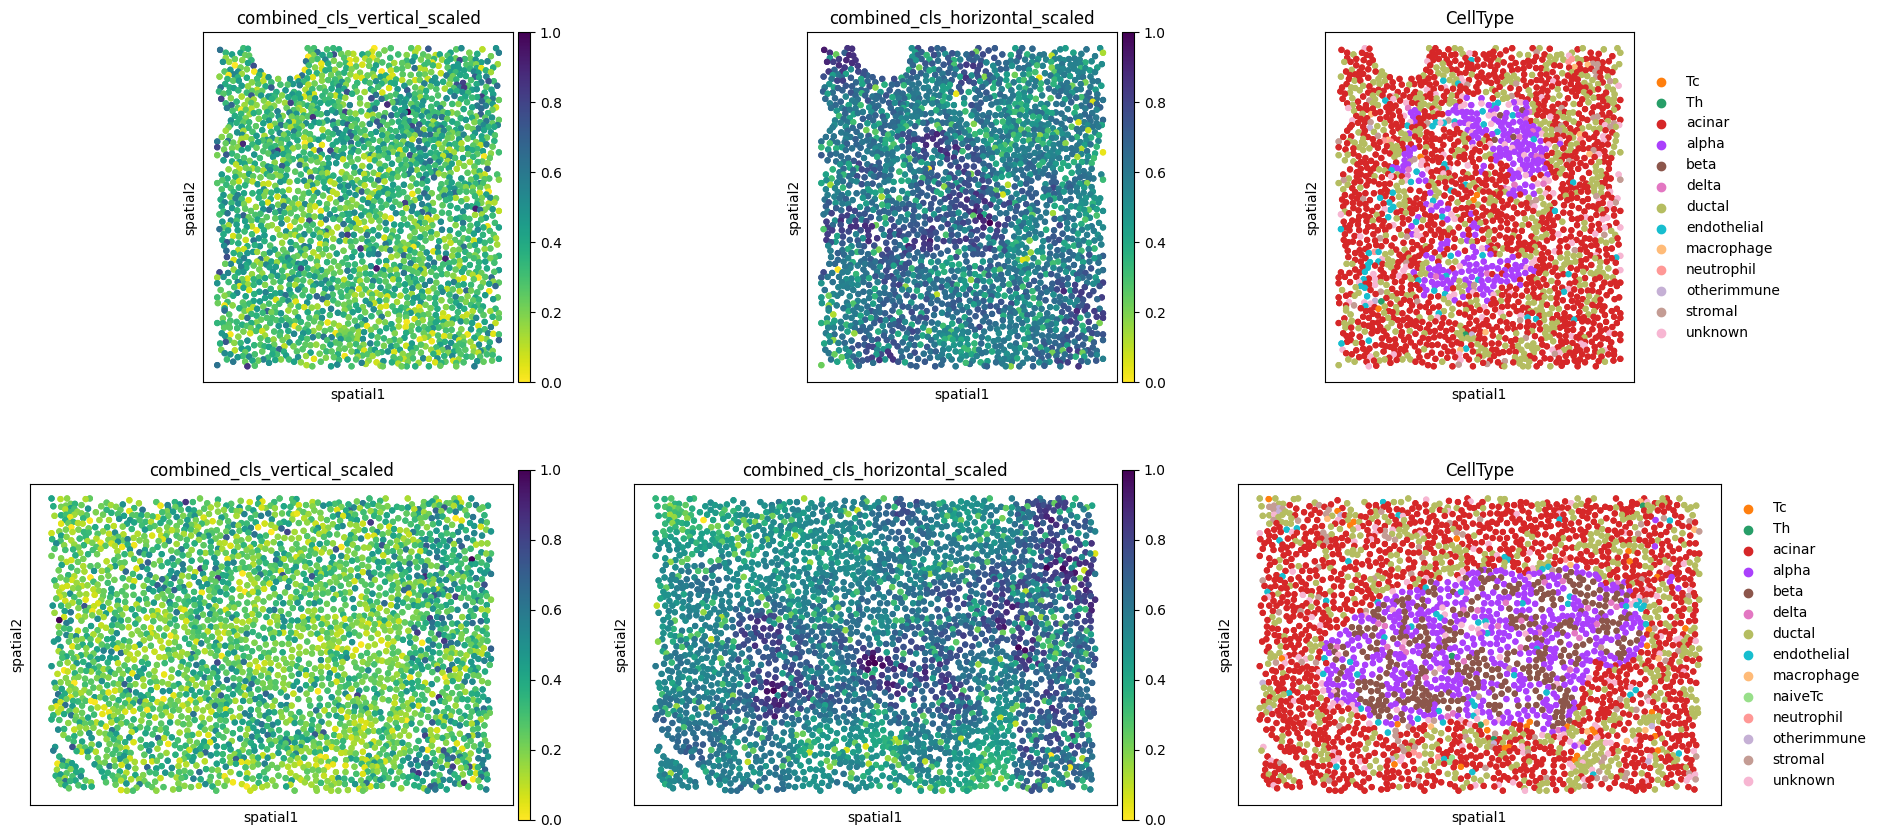

In [59]:
image_nr_onset = np.unique(result_onset.obs['ImageNumber'][result_onset.obs['split'] == 'test'])
image_subset_onset = list(np.random.choice(image_nr_onset, 2))
print(image_subset_onset)
sq.pl.spatial_scatter(result_onset[result_onset.obs['split'] == 'test'], 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', 'CellType'],
                      library_key = 'ImageNumber',
                      library_id = image_subset_onset,
                    cmap = 'viridis_r',
                    shape= None,
                      ncols = 3,
                      size = 50,
                      save = f"{HPC}/InterScale_reproducibility/figures/legnini23/graph_class/"
)

[182, 191]


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


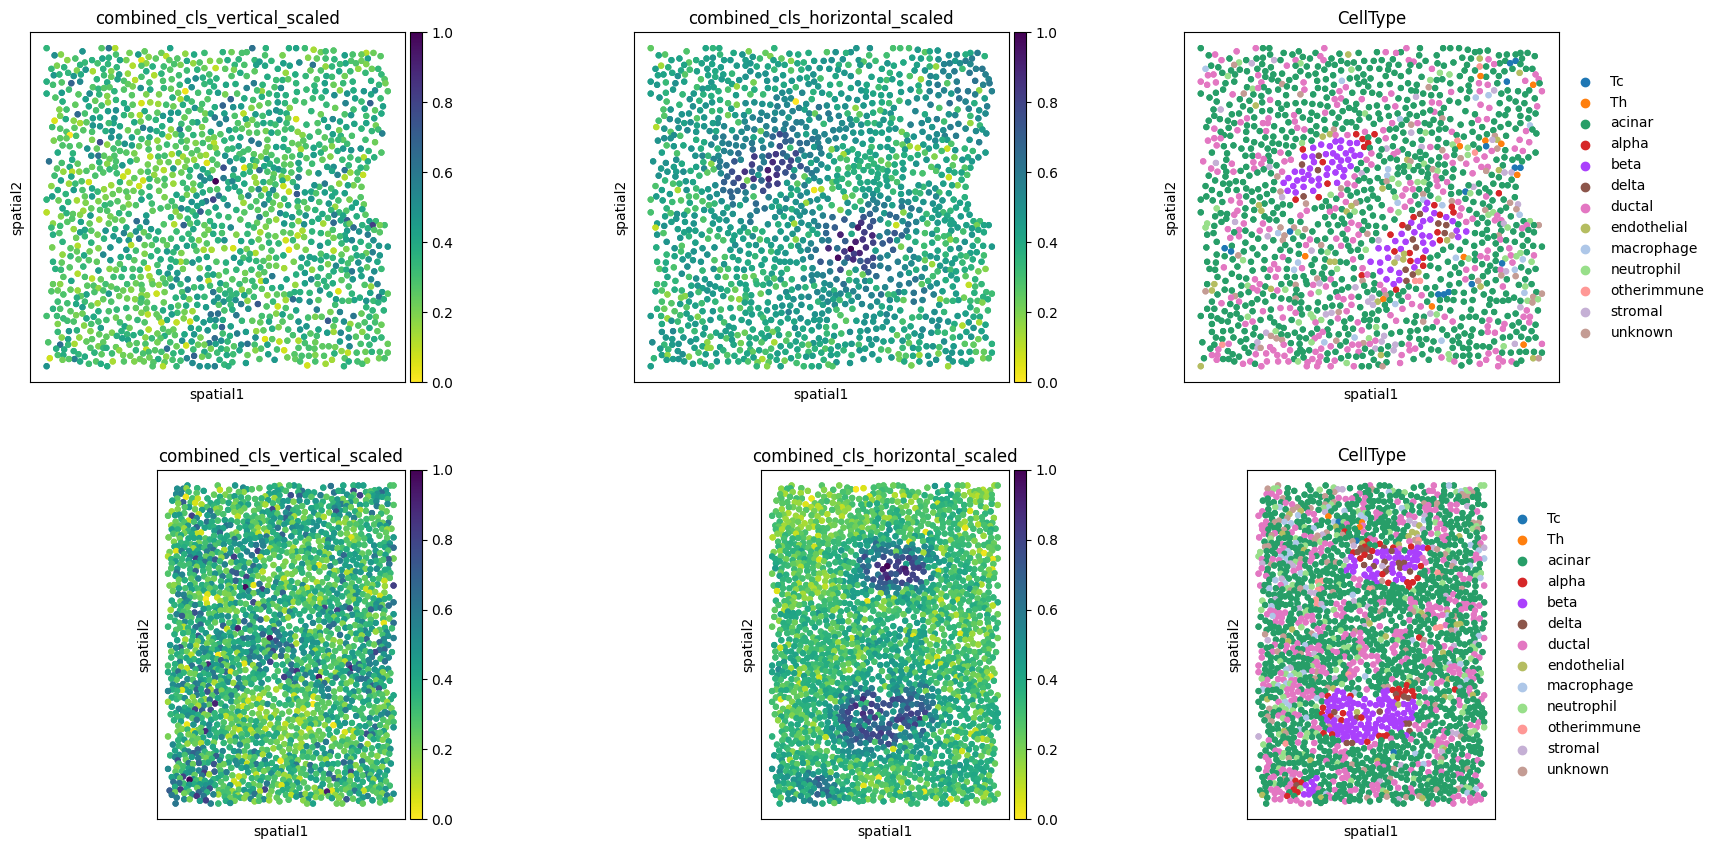

In [58]:
image_nr_nd = np.unique(result_nd.obs['ImageNumber'][result_nd.obs['split'] == 'test'])
image_subset_nd = list(np.random.choice(image_nr_nd, 2))
print(image_subset_nd)
sq.pl.spatial_scatter(result_nd[result_nd.obs['split'] == 'test'], 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', 'CellType'],
                      library_key = 'ImageNumber',
                      library_id = image_subset_nd,
                    cmap = 'viridis_r',
                    shape= None,
                      ncols = 3,
                      size = 50,
                      save = f"{HPC}/InterScale_reproducibility/figures/legnini23/graph_class/"
)

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from typing import List, Dict, Optional, Union


def plot_adata_grouped_heatmaps(
    adata_dict: Dict[str, 'AnnData'],
    group_by: str,
    value_cols: List[str] = None,
    labels: List[str] = None,
    split_key: Optional[str] = 'split',
    split_value: Optional[str] = 'test',
    figsize: tuple = (10, 6),
    save_path: Optional[str] = None,
    cmap: str = 'viridis_r',
    annot: bool = True,
    fmt: str = '.2f',
    linewidth: float = 0.5,
    shared_colorbar: bool = True,
    agg_func: str = 'mean',
    **kwargs
) -> plt.Figure:
    """
    Create side-by-side heatmaps from multiple AnnData objects with shared color scale.
    
    Parameters
    ----------
    adata_dict : Dict[str, AnnData]
        Dictionary with keys as condition names and values as AnnData objects.
        Order of keys determines subplot order.
    group_by : str
        Column name in adata.obs to group by (e.g., 'CellType', 'cluster').
    value_cols : List[str], optional
        List of column names to aggregate. If None, defaults to:
        ['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled']
    labels : List[str], optional
        Subplot titles. If None (default), automatically uses keys from adata_dict.
    split_key : str, optional
        Column name for filtering (e.g., 'split'). Set to None to skip filtering.
    split_value : str, optional
        Value to filter on (e.g., 'test'). Only used if split_key is not None.
    figsize : tuple, default (10, 6)
        Figure size (width, height).
    save_path : str, optional
        Path to save figure. If None, figure is not saved.
    cmap : str, default 'viridis_r'
        Colormap name.
    annot : bool, default True
        Whether to annotate heatmap cells with values.
    fmt : str, default '.2f'
        Format string for annotations.
    linewidth : float, default 0.5
        Width of lines dividing cells.
    shared_colorbar : bool, default True
        Whether to use a shared colorbar (only on last subplot).
    agg_func : str, default 'mean'
        Aggregation function ('mean', 'median', 'sum', etc.).
    **kwargs
        Additional keyword arguments passed to sns.heatmap.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object.
    
    Examples
    --------
    >>> # Basic usage - subplot titles automatically use dict keys ('ND', 'Onset', 'Long')
    >>> adata_dict = {
    ...     'ND': result_nd,
    ...     'Onset': result_onset,
    ...     'Long': result_long
    ... }
    >>> fig = plot_adata_grouped_heatmaps(
    ...     adata_dict=adata_dict,
    ...     group_by='CellType',
    ...     save_path='output/cls_heatmap.png'
    ... )
    
    >>> # Custom columns and no filtering - titles use dict keys
    >>> fig = plot_adata_grouped_heatmaps(
    ...     adata_dict={'Control': adata1, 'Treatment': adata2},
    ...     group_by='cell_type',
    ...     value_cols=['gene_A', 'gene_B', 'gene_C'],
    ...     split_key=None,
    ...     figsize=(12, 5)
    ... )
    
    >>> # Only use custom labels if you want titles different from dict keys
    >>> fig = plot_adata_grouped_heatmaps(
    ...     adata_dict={'cond1': adata1, 'cond2': adata2},
    ...     group_by='CellType',
    ...     labels=['Control Group', 'Treatment Group']  # Optional override
    ... )
    """
    # Set default value columns if not provided
    if value_cols is None:
        value_cols = ['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled']
    
    # Use dict keys as labels if not provided (default behavior)
    if labels is None:
        labels = list(adata_dict.keys())
    else:
        # Validate if custom labels are provided
        if len(labels) != len(adata_dict):
            raise ValueError(f"Number of labels ({len(labels)}) must match number of AnnData objects ({len(adata_dict)})")
    
    # Process each AnnData object and compute aggregated data
    processed_data = {}
    for key, adata in adata_dict.items():
        # Filter by split if specified
        if split_key is not None and split_value is not None:
            if split_key not in adata.obs.columns:
                raise KeyError(f"Column '{split_key}' not found in adata.obs for '{key}'")
            adata_filtered = adata[adata.obs[split_key] == split_value]
        else:
            adata_filtered = adata
        
        # Check if group_by column exists
        if group_by not in adata_filtered.obs.columns:
            raise KeyError(f"Column '{group_by}' not found in adata.obs for '{key}'")
        
        # Check if value columns exist
        for col in value_cols:
            if col not in adata_filtered.obs.columns:
                raise KeyError(f"Column '{col}' not found in adata.obs for '{key}'")
        
        # Create aggregation dictionary
        agg_dict = {f'mean_{col}': (col, agg_func) for col in value_cols}
        
        # Group and aggregate
        processed_data[key] = adata_filtered.obs.groupby(group_by).agg(**agg_dict)
    
    # Calculate shared color scale
    all_values = np.concatenate([df.values.flatten() for df in processed_data.values()])
    vmin = all_values.min()
    vmax = all_values.max()
    
    # Create figure with subplots
    n_plots = len(processed_data)
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    
    # Handle case of single subplot
    if n_plots == 1:
        axes = [axes]
    
    # Plot each heatmap
    for idx, (key, label) in enumerate(zip(adata_dict.keys(), labels)):
        data = processed_data[key]
        
        # Determine if this is the last plot (for colorbar)
        show_cbar = shared_colorbar and (idx == n_plots - 1)
        
        sns.heatmap(
            data,
            annot=annot,
            linewidth=linewidth,
            fmt=fmt,
            ax=axes[idx],
            vmin=vmin,
            vmax=vmax,
            cbar=show_cbar,
            cmap=cmap,
            **kwargs
        )
        axes[idx].set_title(label)
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig